# Regression Detection Evaluation

Aggregates `results/regression/runs.csv` (produced by `run_regression_experiments.py`)
into the metrics reported in Chapter 5, Part 3 of the thesis:

- confusion matrix (TP / FP / FN / TN) and precision / recall / specificity / F1;
- false-positive rate from the control runs;
- detection latency;
- per-regression-type summary (thesis Table `tab:eval_regression`);
- precision / recall vs the P95 degradation threshold.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

runs = pd.read_csv('../results/regression/runs.csv')
print(f'{len(runs)} runs loaded')
runs

12 runs loaded


,regression_type,intensity,metric_id,screen_name,baseline_secs,current_secs,baseline_samples,current_samples,baseline_p95,current_p95,degradation_pct,p_value,candidate,confirmed,expected_regression,outcome,detection_latency_secs,note
0,cpu,1,cpuUsage,compose/cpu_load,40,30,59,38,19.159,105.029,448.20,0.00000,True,True,True,TP,15.0,NaN
1,cpu,2,cpuUsage,compose/cpu_load,40,30,59,40,15.648,55.407,254.08,0.00000,True,True,True,TP,15.0,NaN
2,cpu,3,cpuUsage,compose/cpu_load,40,30,60,40,18.546,92.648,399.57,0.00000,True,True,True,TP,15.0,NaN
3,memory,1,memoryUsage,compose/ram_load,40,30,53,38,70.508,69.838,-0.95,NaN,False,False,True,FN,NaN,NaN
4,memory,2,memoryUsage,compose/ram_load,40,30,55,37,70.590,70.509,-0.12,NaN,False,False,True,FN,NaN,NaN
5,memory,3,memoryUsage,compose/ram_load,40,30,56,38,70.781,71.164,0.54,NaN,False,False,True,FN,NaN,NaN
6,ui,1,frameTime,compose/ui_responsiveness,40,30,60,40,17.305,20.868,20.59,0.00000,True,True,True,TP,15.0,NaN
7,ui,2,frameTime,compose/ui_responsiveness,40,30,59,40,16.667,50.000,200.00,0.00000,True,True,True,TP,15.0,NaN
8,ui,3,frameTime,compose/ui_responsiveness,40,30,60,39,16.695,107.000,540.90,0.00000,True,True,True,TP,15.0,NaN
9,control,0,cpuUsage,compose/cpu_load,40,30,59,40,22.092,15.920,-27.94,NaN,False,False,False,TN,NaN,NaN


## Confusion matrix and classification metrics

In [2]:
tp = int((runs.outcome == 'TP').sum())
fp = int((runs.outcome == 'FP').sum())
fn = int((runs.outcome == 'FN').sum())
tn = int((runs.outcome == 'TN').sum())

precision   = tp / (tp + fp) if (tp + fp) else float('nan')
recall      = tp / (tp + fn) if (tp + fn) else float('nan')
specificity = tn / (tn + fp) if (tn + fp) else float('nan')
f1          = (2 * precision * recall / (precision + recall)
               if precision + recall else float('nan'))
fpr         = fp / (fp + tn) if (fp + tn) else float('nan')

print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print(f'Precision   : {precision:.3f}')
print(f'Recall      : {recall:.3f}  (detection rate / sensitivity)')
print(f'Specificity : {specificity:.3f}')
print(f'F1-score    : {f1:.3f}')
print(f'False-positive rate : {fpr:.3f}')

TP=6  FP=1  FN=3  TN=2
Precision   : 0.857
Recall      : 0.667  (detection rate / sensitivity)
Specificity : 0.667
F1-score    : 0.750
False-positive rate : 0.333


## Per-regression-type summary (thesis Table 5.4)

One row per regression type, averaged over the repetitions of the medium
intensity level (intensity 2). Adjust the intensity filter if needed.

In [3]:
injected = runs[runs.regression_type != 'control']
med = injected[injected.intensity == 2]
summary = (med.groupby('regression_type')
              .agg(metric=('metric_id', 'first'),
                   baseline_p95=('baseline_p95', 'mean'),
                   current_p95=('current_p95', 'mean'),
                   degradation_pct=('degradation_pct', 'mean'),
                   p_value=('p_value', 'mean'),
                   detected=('confirmed', 'all'))
              .round(3))
summary

,metric,baseline_p95,current_p95,degradation_pct,p_value,detected
regression_type,,,,,,
cpu,cpuUsage,15.648,55.407,254.08,0.0,True
memory,memoryUsage,70.590,70.509,-0.12,NaN,False
ui,frameTime,16.667,50.000,200.00,0.0,True


## Control runs (false alerts)

Expected outcome: zero confirmed regressions.

In [4]:
control = runs[runs.regression_type == 'control']
print(f'{len(control)} control runs')
print(f'  candidate regressions : {int(control.candidate.sum())}')
print(f'  confirmed regressions : {int(control.confirmed.sum())}')
missed = int((injected.outcome == 'FN').sum())
print(f'\nFalse negatives: {missed} of {len(injected)} injected regressions missed')

3 control runs
  candidate regressions : 1
  confirmed regressions : 1

False negatives: 3 of 9 injected regressions missed


## Detection latency

count     6.0
mean     15.0
std       0.0
min      15.0
25%      15.0
50%      15.0
75%      15.0
max      15.0
Name: detection_latency_secs, dtype: float64


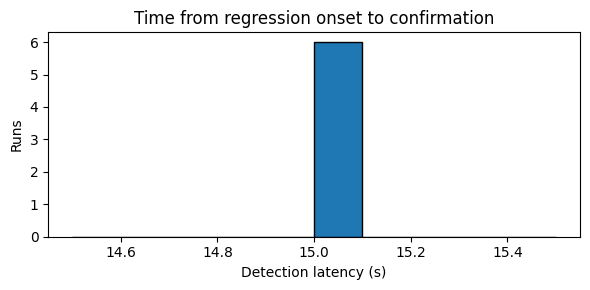

In [5]:
lat = runs.detection_latency_secs.dropna()
if len(lat):
    print(lat.describe())
    plt.figure(figsize=(6, 3))
    plt.hist(lat, bins=10, edgecolor='black')
    plt.xlabel('Detection latency (s)')
    plt.ylabel('Runs')
    plt.title('Time from regression onset to confirmation')
    plt.tight_layout()
    plt.show()
else:
    print('No confirmed regressions with a recorded latency.')

## Measured degradation vs injected intensity

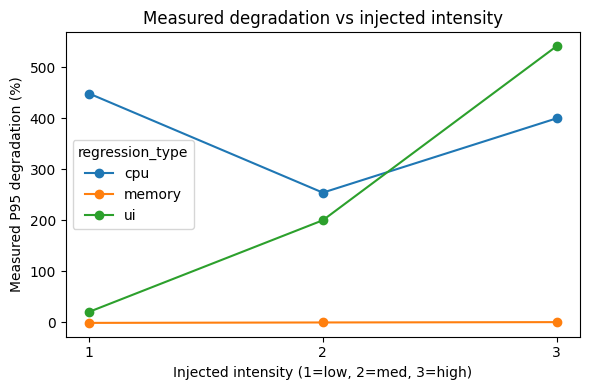

regression_type,cpu,memory,ui
intensity,,,
1,448.20,-0.95,20.59
2,254.08,-0.12,200.00
3,399.57,0.54,540.90


In [6]:
pivot = (injected.groupby(['regression_type', 'intensity'])
                 .degradation_pct.mean().unstack('regression_type'))
ax = pivot.plot(marker='o', figsize=(6, 4))
ax.set_xlabel('Injected intensity (1=low, 2=med, 3=high)')
ax.set_ylabel('Measured P95 degradation (%)')
ax.set_title('Measured degradation vs injected intensity')
ax.set_xticks([1, 2, 3])
plt.tight_layout()
plt.show()
pivot.round(2)

## Precision / recall vs the P95 degradation threshold

Re-derives the candidate/confirmed decision at a range of thresholds using the
degradation and p-value already recorded per run. The Mann-Whitney gate
(p < 0.05) is threshold-independent.

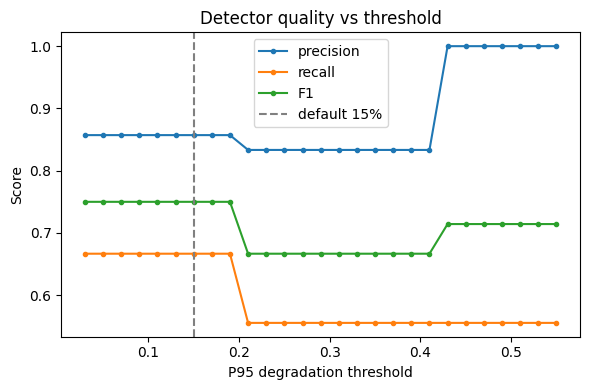

Best F1 = 0.750 at threshold 0.03


In [7]:
thresholds = np.arange(0.03, 0.56, 0.02)
rows = []
for thr in thresholds:
    candidate = (runs.degradation_pct / 100.0) > thr
    sig = runs.p_value.notna() & (runs.p_value < 0.05)
    confirmed = candidate & sig
    exp = runs.expected_regression
    tp_ = int((confirmed & exp).sum())
    fp_ = int((confirmed & ~exp).sum())
    fn_ = int((~confirmed & exp).sum())
    p = tp_ / (tp_ + fp_) if (tp_ + fp_) else np.nan
    r = tp_ / (tp_ + fn_) if (tp_ + fn_) else np.nan
    f = 2 * p * r / (p + r) if (p and r and p + r) else np.nan
    rows.append((thr, p, r, f))

sweep = pd.DataFrame(rows, columns=['threshold', 'precision', 'recall', 'f1'])
plt.figure(figsize=(6, 4))
plt.plot(sweep.threshold, sweep.precision, marker='.', label='precision')
plt.plot(sweep.threshold, sweep.recall, marker='.', label='recall')
plt.plot(sweep.threshold, sweep.f1, marker='.', label='F1')
plt.axvline(0.15, color='grey', linestyle='--', label='default 15%')
plt.xlabel('P95 degradation threshold')
plt.ylabel('Score')
plt.title('Detector quality vs threshold')
plt.legend()
plt.tight_layout()
plt.show()
best = sweep.loc[sweep.f1.idxmax()]
print(f"Best F1 = {best.f1:.3f} at threshold {best.threshold:.2f}")